# Iris exploratory Data Analysis (EDA)

In [1]:
# Load the iris dataset
data(iris)

# Inspect the data
dim(iris)          # shape of the dataset
head(iris)         # first 6 rows
str(iris)          # structure and types
summary(iris)      # summary statistics


[1] 150   5

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
,<dbl>,<dbl>,<dbl>,<dbl>,<fct>
1,5.1,3.5,1.4,0.2,setosa
2,4.9,3.0,1.4,0.2,setosa
3,4.7,3.2,1.3,0.2,setosa
4,4.6,3.1,1.5,0.2,setosa
5,5.0,3.6,1.4,0.2,setosa
6,5.4,3.9,1.7,0.4,setosa


'data.frame':	150 obs. of  5 variables:
 $ Sepal.Length: num  5.1 4.9 4.7 4.6 5 5.4 4.6 5 4.4 4.9 ...
 $ Sepal.Width : num  3.5 3 3.2 3.1 3.6 3.9 3.4 3.4 2.9 3.1 ...
 $ Petal.Length: num  1.4 1.4 1.3 1.5 1.4 1.7 1.4 1.5 1.4 1.5 ...
 $ Petal.Width : num  0.2 0.2 0.2 0.2 0.2 0.4 0.3 0.2 0.2 0.1 ...
 $ Species     : Factor w/ 3 levels "setosa","versicolor",..: 1 1 1 1 1 1 1 1 1 1 ...


  Sepal.Length    Sepal.Width     Petal.Length    Petal.Width   
 Min.   :4.300   Min.   :2.000   Min.   :1.000   Min.   :0.100  
 1st Qu.:5.100   1st Qu.:2.800   1st Qu.:1.600   1st Qu.:0.300  
 Median :5.800   Median :3.000   Median :4.350   Median :1.300  
 Mean   :5.843   Mean   :3.057   Mean   :3.758   Mean   :1.199  
 3rd Qu.:6.400   3rd Qu.:3.300   3rd Qu.:5.100   3rd Qu.:1.800  
 Max.   :7.900   Max.   :4.400   Max.   :6.900   Max.   :2.500  
       Species  
 setosa    :50  
 versicolor:50  
 virginica :50  
                
                
                

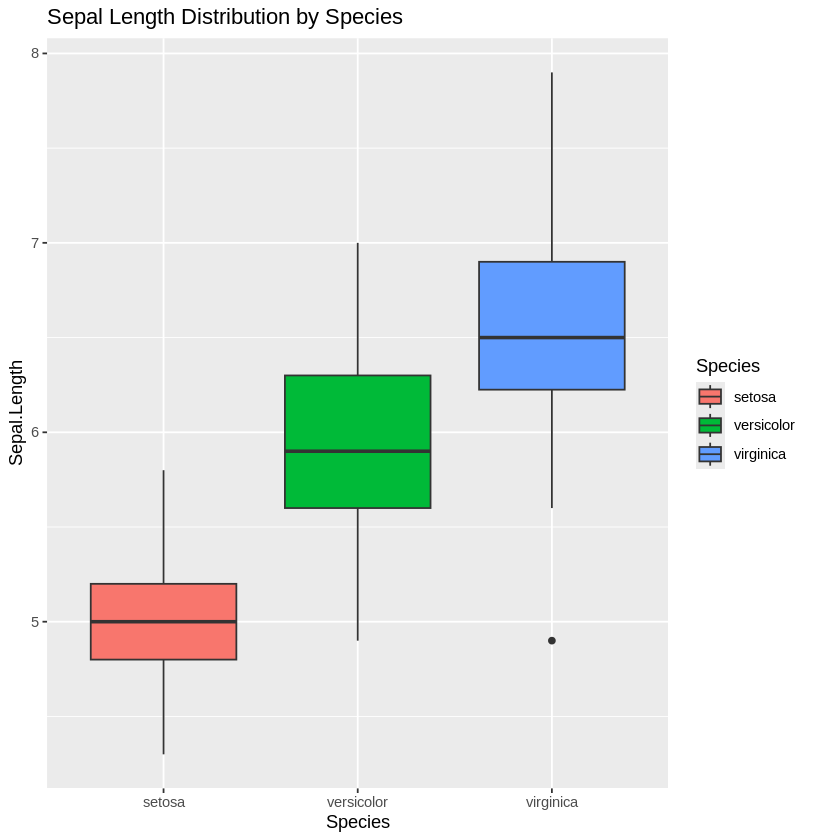

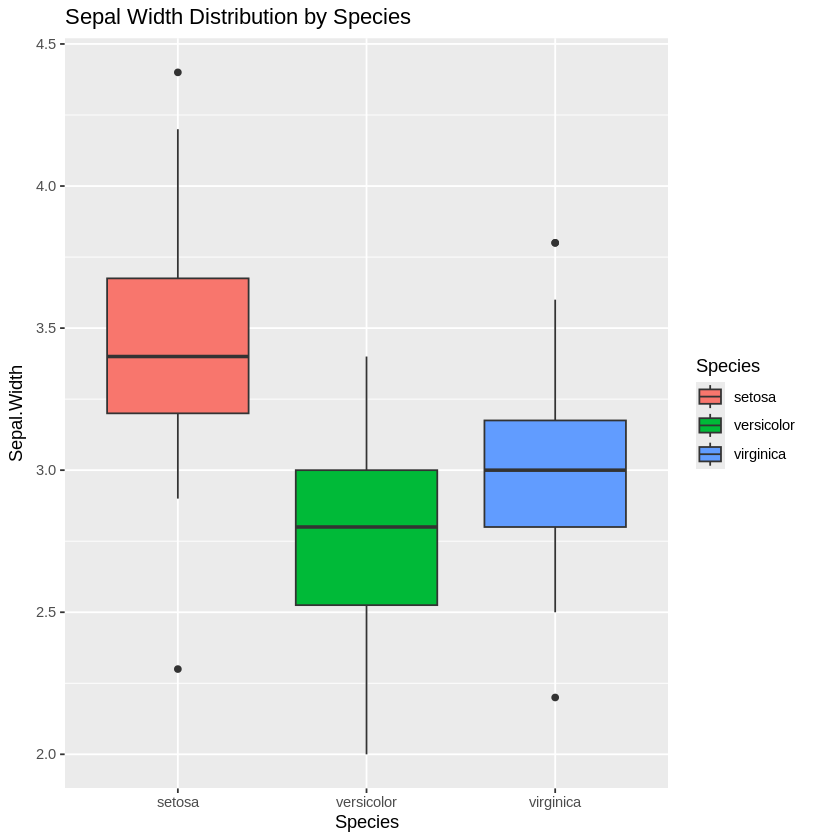

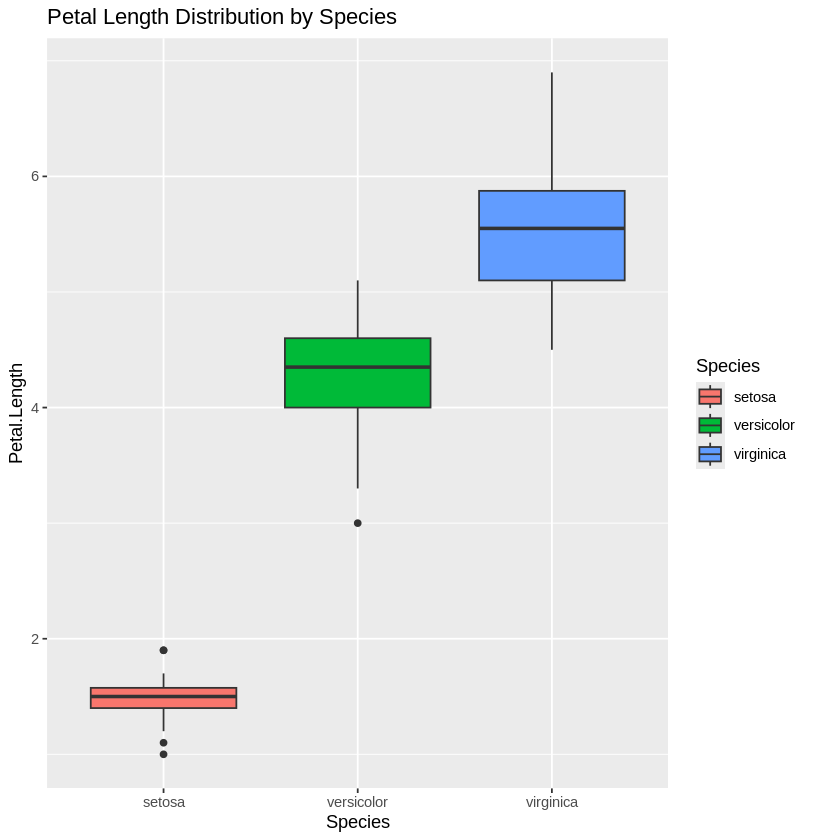

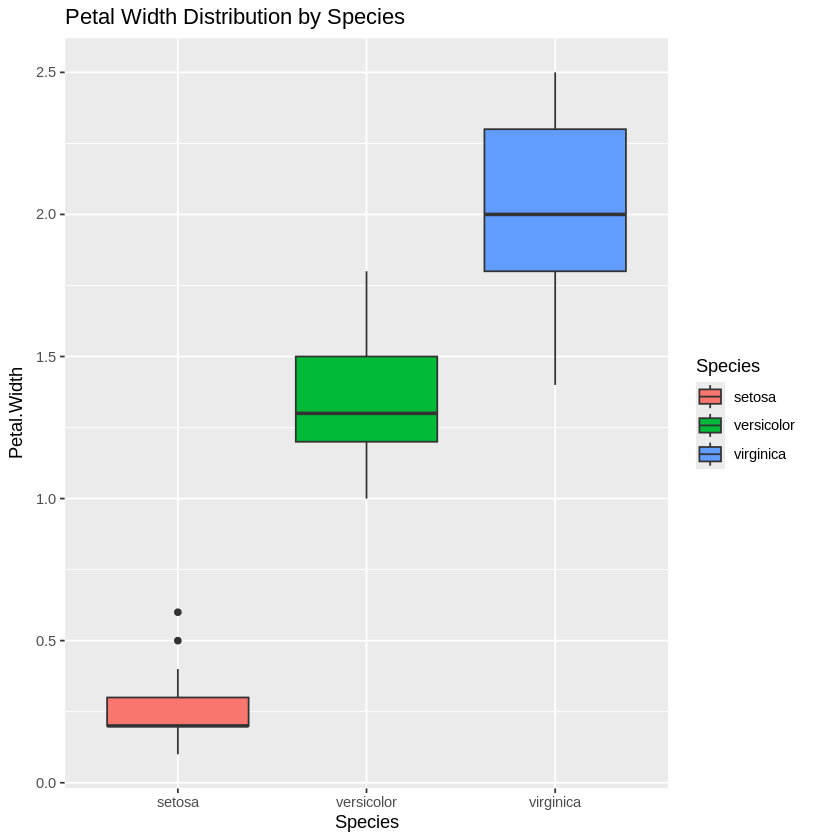

In [2]:
library(ggplot2)

# Sepal Length distribution
ggplot(iris, aes(x = Species, y = Sepal.Length, fill = Species)) +
  geom_boxplot() +
  ggtitle("Sepal Length Distribution by Species")

# Sepal Width distribution
ggplot(iris, aes(x = Species, y = Sepal.Width, fill = Species)) +
  geom_boxplot() +
  ggtitle("Sepal Width Distribution by Species")

# Petal Length distribution
ggplot(iris, aes(x = Species, y = Petal.Length, fill = Species)) +
  geom_boxplot() +
  ggtitle("Petal Length Distribution by Species")

# Petal Width distribution
ggplot(iris, aes(x = Species, y = Petal.Width, fill = Species)) +
  geom_boxplot() +
  ggtitle("Petal Width Distribution by Species")


In [3]:
install.packages("corrplot")
library(corrplot)


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

corrplot 0.95 loaded



             Sepal.Length Sepal.Width Petal.Length Petal.Width
Sepal.Length    1.0000000  -0.1175698    0.8717538   0.8179411
Sepal.Width    -0.1175698   1.0000000   -0.4284401  -0.3661259
Petal.Length    0.8717538  -0.4284401    1.0000000   0.9628654
Petal.Width     0.8179411  -0.3661259    0.9628654   1.0000000


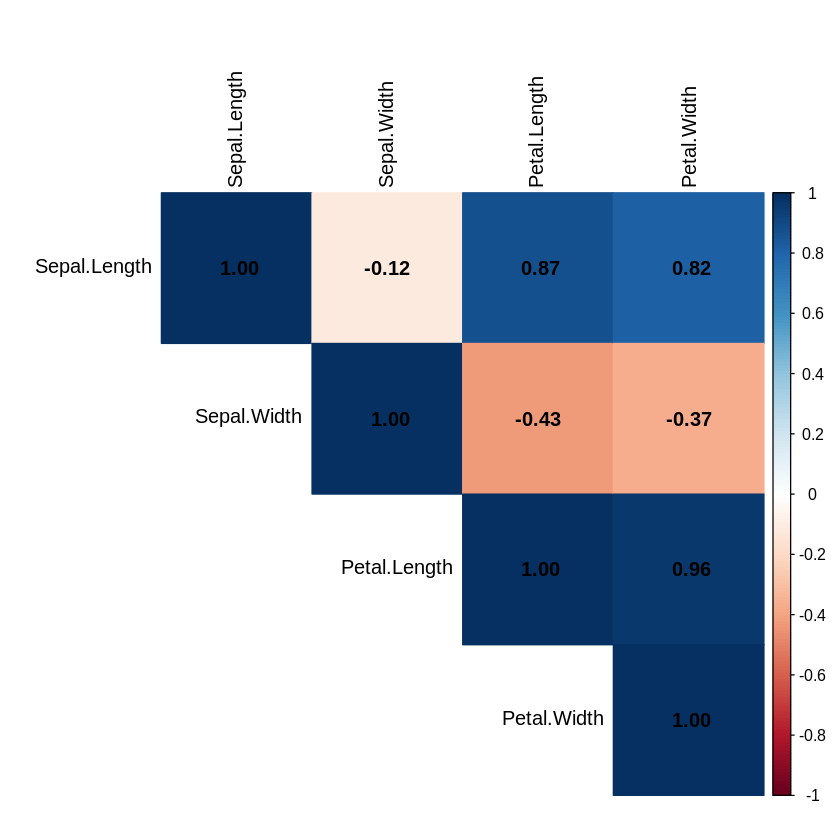

In [4]:
# Compute correlation matrix (excluding Species)
cor_matrix <- cor(iris[, 1:4])
print(cor_matrix)

# Visualize with a heatmap
library(corrplot)
corrplot(cor_matrix, method = "color", type = "upper", tl.col = "black", addCoef.col = "black")


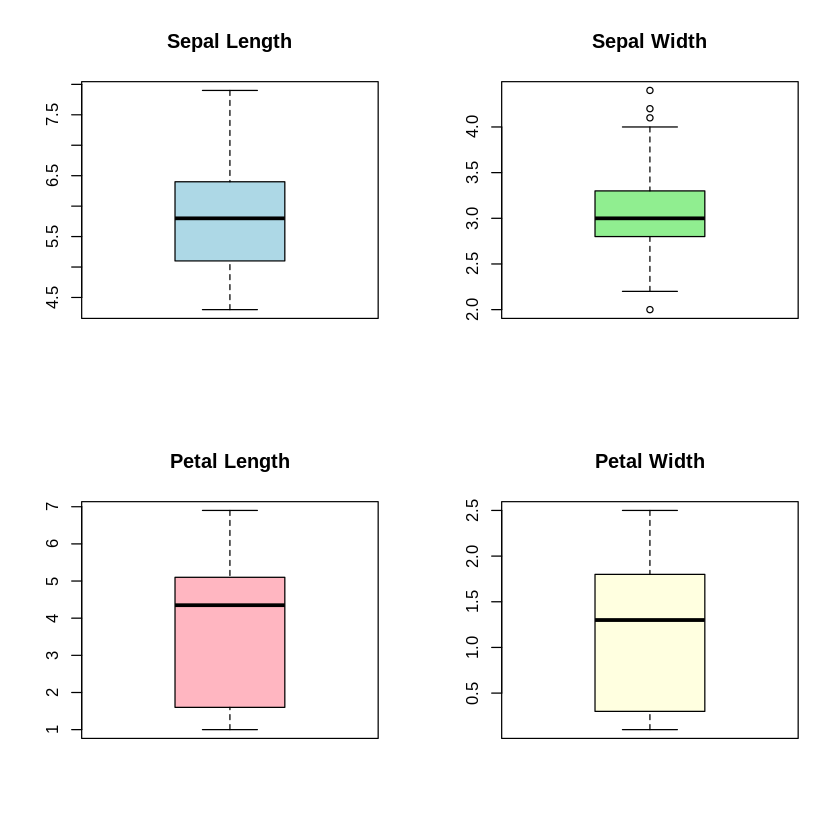

In [5]:
# Boxplots for outlier detection
par(mfrow = c(2, 2))
boxplot(iris$Sepal.Length, main = "Sepal Length", col = "lightblue")
boxplot(iris$Sepal.Width, main = "Sepal Width", col = "lightgreen")
boxplot(iris$Petal.Length, main = "Petal Length", col = "lightpink")
boxplot(iris$Petal.Width, main = "Petal Width", col = "lightyellow")


In [6]:
install.packages("GGally")
library(GGally)
library(ggplot2)


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘patchwork’, ‘ggstats’




Warning message in geom_boxplot(mapping, ...):
“Ignoring unknown aesthetics: title”
Warning message in geom_boxplot(mapping, ...):
“Ignoring unknown aesthetics: title”
Warning message in geom_boxplot(mapping, ...):
“Ignoring unknown aesthetics: title”
Warning message in geom_boxplot(mapping, ...):
“Ignoring unknown aesthetics: title”
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.


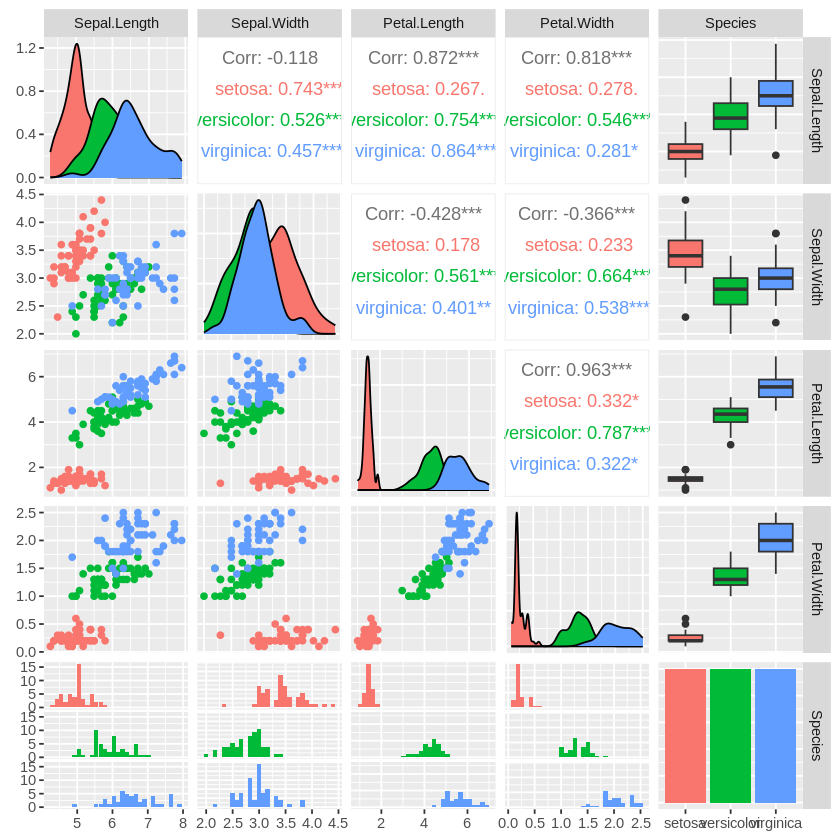

In [7]:
# Pair plot with labeled colors for species
ggpairs(iris, aes(color = Species, title = "Pairwise Relationships of Iris Features"))



In [9]:
# Load dataset again (if needed)
data(iris)

# Create train/test split
set.seed(123)
library(caret)

index <- createDataPartition(iris$Species, p = 0.8, list = FALSE)
train_data <- iris[index, ]
test_data <- iris[-index, ]

dim(train_data)
dim(test_data)


[1] 120   5

[1] 30  5

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



Confusion Matrix and Statistics

            Reference
Prediction   setosa versicolor virginica
  setosa         10          0         0
  versicolor      0         10         2
  virginica       0          0         8

Overall Statistics
                                          
               Accuracy : 0.9333          
                 95% CI : (0.7793, 0.9918)
    No Information Rate : 0.3333          
    P-Value [Acc > NIR] : 8.747e-12       
                                          
                  Kappa : 0.9             
                                          
 Mcnemar's Test P-Value : NA              

Statistics by Class:

                     Class: setosa Class: versicolor Class: virginica
Sensitivity                 1.0000            1.0000           0.8000
Specificity                 1.0000            0.9000           1.0000
Pos Pred Value              1.0000            0.8333           1.0000
Neg Pred Value              1.0000            1.0000           0.9091
P

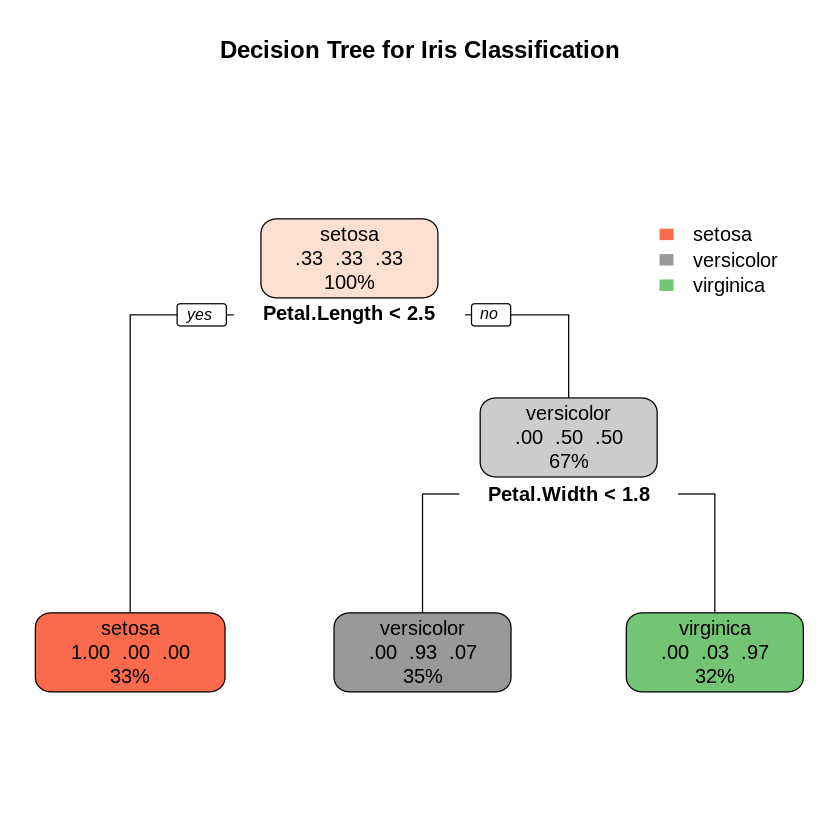

In [10]:
# Install required packages if not already
install.packages("rpart")
install.packages("rpart.plot")
install.packages("caret")

# Load libraries
library(rpart)
library(rpart.plot)
library(caret)

# Train a Decision Tree
set.seed(123)
dt_model <- rpart(Species ~ ., data = train_data, method = "class")

# Visualize the tree
rpart.plot(dt_model, main = "Decision Tree for Iris Classification")

# Predict on test data
dt_predictions <- predict(dt_model, test_data, type = "class")

# Evaluate performance
conf_mat <- confusionMatrix(dt_predictions, test_data$Species)
print(conf_mat)


In [11]:
# Install and load required package
install.packages("e1071")
library(e1071)
library(caret)

# Train SVM model
svm_model <- svm(Species ~ ., data = train_data, kernel = "linear")

# Predict on test data
svm_predictions <- predict(svm_model, test_data)

# Evaluate performance
conf_mat_svm <- confusionMatrix(svm_predictions, test_data$Species)
print(conf_mat_svm)


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)


Attaching package: ‘e1071’


The following object is masked from ‘package:ggplot2’:

    element




Confusion Matrix and Statistics

            Reference
Prediction   setosa versicolor virginica
  setosa         10          0         0
  versicolor      0         10         1
  virginica       0          0         9

Overall Statistics
                                          
               Accuracy : 0.9667          
                 95% CI : (0.8278, 0.9992)
    No Information Rate : 0.3333          
    P-Value [Acc > NIR] : 2.963e-13       
                                          
                  Kappa : 0.95            
                                          
 Mcnemar's Test P-Value : NA              

Statistics by Class:

                     Class: setosa Class: versicolor Class: virginica
Sensitivity                 1.0000            1.0000           0.9000
Specificity                 1.0000            0.9500           1.0000
Pos Pred Value              1.0000            0.9091           1.0000
Neg Pred Value              1.0000            1.0000           0.9524
P

In [12]:
# Install and load required packages
install.packages("class")
library(class)
library(caret)

# Prepare data (exclude species column for predictors)
train_x <- train_data[, -5]
train_y <- train_data$Species
test_x  <- test_data[, -5]
test_y  <- test_data$Species

# Choose k = 5 (common default)
set.seed(123)
knn_predictions <- knn(train = train_x, test = test_x, cl = train_y, k = 5)

# Evaluate performance
conf_mat_knn <- confusionMatrix(knn_predictions, test_y)
print(conf_mat_knn)


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



Confusion Matrix and Statistics

            Reference
Prediction   setosa versicolor virginica
  setosa         10          0         0
  versicolor      0         10         0
  virginica       0          0        10

Overall Statistics
                                     
               Accuracy : 1          
                 95% CI : (0.8843, 1)
    No Information Rate : 0.3333     
    P-Value [Acc > NIR] : 4.857e-15  
                                     
                  Kappa : 1          
                                     
 Mcnemar's Test P-Value : NA         

Statistics by Class:

                     Class: setosa Class: versicolor Class: virginica
Sensitivity                 1.0000            1.0000           1.0000
Specificity                 1.0000            1.0000           1.0000
Pos Pred Value              1.0000            1.0000           1.0000
Neg Pred Value              1.0000            1.0000           1.0000
Prevalence                  0.3333            